# Deliverable 1 — Basic Network Construction & Structural Analysis

Self-contained notebook. Loads the dataset, builds the anime co-watch network,
characterises its degree distribution and power-law exponent, computes clustering
and average shortest path length, analyses the giant connected component, and
compares against an Erdős–Rényi null model.

In [12]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# python-louvain exports community.best_partition; a different 'community' pkg may be installed
try:
    import community as _c
    _ = _c.best_partition   # raises AttributeError if wrong package
except (ImportError, AttributeError):
    print('Installing python-louvain...')
    pip_install('python-louvain')

try:
    import powerlaw
except ImportError:
    print('Installing powerlaw...')
    pip_install('powerlaw')

try:
    import seaborn
except ImportError:
    pip_install('seaborn')

print('All packages ready.')

Installing python-louvain...
All packages ready.


In [13]:
import warnings
warnings.filterwarnings('ignore')

import os, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from scipy import sparse, stats
from scipy.sparse import csr_matrix
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations

try:
    import community as community_louvain
    _ = community_louvain.best_partition  # verify it's python-louvain
    HAVE_LOUVAIN = True
except (ImportError, AttributeError):
    HAVE_LOUVAIN = False
    print('python-louvain unavailable — will use NetworkX greedy modularity')

try:
    import powerlaw as pl_lib
    HAVE_POWERLAW = True
except ImportError:
    HAVE_POWERLAW = False

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

# --- Auto-detect dataset path (works on Kaggle regardless of dataset slug) ---
_candidates = [
    '/kaggle/input/datasets/shamiksinha/anime-dataset-nsproject',
    '/kaggle/input/anime-dataset-nsproject',
    '/kaggle/input/anime-recommendation-database',
]
DATA_PATH = None
for _c in _candidates:
    if os.path.isfile(os.path.join(_c, 'anime.csv')):
        DATA_PATH = _c
        break
if DATA_PATH is None:
    _hits = glob.glob('/kaggle/input/**/anime.csv', recursive=True)
    if _hits:
        DATA_PATH = os.path.dirname(_hits[0])
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find anime.csv under /kaggle/input/.\n"
        "Make sure the dataset is attached to this notebook. "
        "Files found under /kaggle/input/: " + str(os.listdir('/kaggle/input/'))
    )

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STATUS_MAP = {1: 'Watching', 2: 'Completed', 3: 'On Hold', 4: 'Dropped', 6: 'Plan to Watch'}

print('Imports done.')
print(f'NetworkX version: {nx.__version__}')
print(f'Louvain available: {HAVE_LOUVAIN}')
print(f'powerlaw available: {HAVE_POWERLAW}')
print(f'Data path auto-detected: {DATA_PATH}')
print(f'Files: {os.listdir(DATA_PATH)}')

python-louvain unavailable — will use NetworkX greedy modularity
Imports done.
NetworkX version: 3.6.1
Louvain available: False
powerlaw available: True
Data path auto-detected: /kaggle/input/datasets/shamiksinha/anime-dataset-nsproject
Files: ['html folder', 'watching_status.csv', 'rating_complete.csv', 'animelist.csv', 'anime.csv', 'anime_with_synopsis.csv']


## Data Loading & Preprocessing

We load two main files:
- **`anime.csv`** — metadata for each anime (title, genres, type, air date, scores, member counts)
- **`animelist.csv`** — 109M+ user–anime interaction rows (user_id, anime_id, rating, watching_status, watched_episodes)

Because `animelist.csv` is very large, we sample users with `user_id ≤ 9999`. Since the file is sorted by `user_id`, we can stop reading early, giving us ~3M rows covering ~10,000 users — a large, representative sample.

In [14]:
# Load anime metadata
anime_df = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'), low_memory=False)
anime_df.rename(columns={'MAL_ID': 'anime_id'}, inplace=True)

# Parse air year from 'Aired' column
def parse_year(aired_str):
    if pd.isna(aired_str) or aired_str == 'Unknown':
        return np.nan
    import re
    match = re.search(r'(\d{4})', str(aired_str))
    return int(match.group(1)) if match else np.nan

anime_df['air_year'] = anime_df['Aired'].apply(parse_year)

# Convert score to numeric
anime_df['Score'] = pd.to_numeric(anime_df['Score'], errors='coerce')
anime_df['Members'] = pd.to_numeric(anime_df['Members'], errors='coerce')

# Build quick lookup: anime_id -> name, genres
anime_lookup = anime_df.set_index('anime_id')[['Name','Genres','Type','air_year','Score','Members']]

print(f'Anime metadata loaded: {anime_df.shape[0]} anime titles')
print(f'Year range (non-null): {int(anime_df["air_year"].min())} – {int(anime_df["air_year"].max())}')
print(f'Genres sample: {anime_df["Genres"].dropna().iloc[0]}')
anime_df[['anime_id','Name','Score','Genres','Type','air_year','Members']].head(5)

Anime metadata loaded: 17562 anime titles
Year range (non-null): 1917 – 2022
Genres sample: Action, Adventure, Comedy, Drama, Sci-Fi, Space


,anime_id,Name,Score,Genres,Type,air_year,Members
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,1998.0,1251960
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Movie,2001.0,273145
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",TV,1998.0,558913
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",TV,2002.0,94683
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",TV,2004.0,13224


In [15]:
# Load animelist — two sampling strategies available:
#
#   FAST (default):  users 0–9,999 → ~3M rows, loads in ~10s
#                    Bias: early MAL users, skews toward older anime & power users
#
#   REPRESENTATIVE:  modulo-hash sample (every 30th user_id across full file) → ~3.6M rows
#                    reads all 109M rows (~3-5 min on Kaggle), but spreads evenly over all users
#
# Set REPRESENTATIVE_SAMPLE = True to use the slower but unbiased version.

REPRESENTATIVE_SAMPLE = True   # flip to True for unbiased sampling

CHUNK = 500_000
chunks = []

if not REPRESENTATIVE_SAMPLE:
    SAMPLE_MAX_UID = 9999
    print(f'Loading animelist (fast mode: users 0–{SAMPLE_MAX_UID})...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] <= SAMPLE_MAX_UID]
        chunks.append(sub)
        if chunk['user_id'].max() > SAMPLE_MAX_UID:
            break
else:
    MODULO = 10   # keep every 30th user_id → ~1/30 of all users, spread across full range
    print(f'Loading animelist (representative mode: user_id % {MODULO} == 0, reads full file)...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] % MODULO == 0]
        chunks.append(sub)

animelist = pd.concat(chunks, ignore_index=True)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Shape: {animelist.shape}')
print(f'Unique users:  {animelist["user_id"].nunique():,}')
print(f'Unique anime:  {animelist["anime_id"].nunique():,}')

print('\nWatching status breakdown:')
status_counts = animelist['watching_status'].map(STATUS_MAP).value_counts()
for status, count in status_counts.items():
    print(f'  {status:<18}: {count:>9,} rows ({100*count/len(animelist):.1f}%)')

Loading animelist (representative mode: user_id % 10 == 0, reads full file)...
Loaded in 25.7s
Shape: (11002813, 5)
Unique users:  32,575
Unique anime:  17,551

Watching status breakdown:
  Completed         : 6,860,393 rows (62.4%)
  Plan to Watch     : 2,791,683 rows (25.4%)
  Watching          :   518,253 rows (4.7%)
  Dropped           :   453,575 rows (4.1%)
  On Hold           :   378,892 rows (3.4%)


## Working DataFrames — Column Reference

After loading, we work with two core DataFrames throughout the notebook:

---

### `anime_df` — Anime Metadata Table
Shape: ~17,562 rows × 36 columns. Each row is one anime title.

| Column | Type | Description |
|--------|------|-------------|
| `anime_id` | int | Unique anime ID (renamed from `MAL_ID`). Primary key — used to join with `animelist`. |
| `Name` | str | Canonical romanized title |
| `Score` | float | Weighted average community rating (1–10). `NaN` if not enough votes. |
| `Genres` | str | Comma-separated genre tags, e.g. `"Action, Adventure, Comedy"`. We split on `,` to get individual genres. |
| `Type` | str | Format of the release: `TV`, `Movie`, `OVA`, `ONA`, `Special`, `Music` |
| `Episodes` | str | Episode count (`"Unknown"` for ongoing/unknown) |
| `Aired` | str | Raw air date string, e.g. `"Apr 3, 1998 to Apr 24, 1999"`. We parse the first 4-digit year from this → `air_year`. |
| `Members` | int | Total number of MAL users who have this title in any list — proxy for popularity |
| `Completed` | int | Aggregate count of users who marked it completed |
| `Dropped` | int | Aggregate count of users who dropped it |
| `Watching` | int | Aggregate count currently watching |
| `Plan to Watch` | int | Aggregate count planning to watch |
| `Favorites` | int | Number of users who marked it as a favourite |
| `Score-1` … `Score-10` | float | Distribution of individual ratings (how many users gave each score) |
| `air_year` *(derived)* | float | Parsed 4-digit start year from `Aired`. Used in Deliverable 5 for temporal snapshots. |

---

### `animelist` — User Interaction Log (sampled)
Shape: ~3M rows × 5 columns. Each row is one user's record for one anime.

| Column | Type | Description |
|--------|------|-------------|
| `user_id` | int | Anonymous user identifier. We sample users `0–9999` to keep the dataset tractable. |
| `anime_id` | int | Links to `anime_df`. The anime this row refers to. |
| `rating` | int | User's personal rating (1–10). `0` means the user didn't leave a rating. |
| `watching_status` | int | Current engagement status: `1` Watching · `2` **Completed** · `3` On Hold · `4` **Dropped** · `6` **Plan to Watch** |
| `watched_episodes` | int | Number of episodes the user has watched so far |

> **How these two tables connect:** `animelist.anime_id` → `anime_df.anime_id`. The `animelist` table tells us *who* watched *what* and *how*, while `anime_df` tells us the properties of each title. Most of the network construction work happens on `animelist`, and `anime_df` provides node attributes (genre, score, year, etc.).

---
## Deliverable 1 — Basic Network Construction & Structural Analysis

We build an **anime co-watch network** where two anime are connected by an edge if a significant number of users have *completed* both. The edge weight equals the co-completion count.

**Construction strategy:** We filter to `watching_status = 2` (Completed), restrict to the top 2,000 most-completed anime (to keep the network tractable), then build a sparse user–anime matrix `M`. The co-occurrence matrix `C = MᵀM` gives us edge weights directly. We threshold at ≥ 15 co-completions.

We then characterize the network using:
- Degree distribution (linear and log-log)
- Power-law exponent estimation
- Clustering coefficient and average shortest path length
- Giant connected component (GCC) analysis
- Comparison against an Erdős–Rényi null model

In [29]:
# --- Build co-watch network ---
# TOP_N_ANIME   = 500   # restrict to most-completed anime
# MIN_COWATCH   = 1000     # minimum co-completions to add edge

# TOP_N_ANIME   = 1000   # restrict to most-completed anime
# MIN_COWATCH   = 1750   # minimum co-completions to add edge

TOP_N_ANIME   = 1000   # restrict to most-completed anime
MIN_COWATCH   = 2000   # minimum co-completions to add edge

# Filter completed interactions
completed = animelist[animelist['watching_status'] == 2][['user_id','anime_id']].copy()

# Keep only top-N most completed anime
top_anime_ids = completed['anime_id'].value_counts().head(TOP_N_ANIME).index
completed = completed[completed['anime_id'].isin(top_anime_ids)]

# Also filter: keep users who completed at least 3 of the top anime
user_counts = completed.groupby('user_id')['anime_id'].count()
active_users = user_counts[user_counts >= 3].index
completed = completed[completed['user_id'].isin(active_users)]

print(f'Filtered completed interactions: {len(completed):,}')
print(f'Users in this set: {completed["user_id"].nunique():,}')
print(f'Anime in this set: {completed["anime_id"].nunique():,}')

# Encode indices
u_enc = LabelEncoder(); a_enc = LabelEncoder()
u_idx = u_enc.fit_transform(completed['user_id'])
a_idx = a_enc.fit_transform(completed['anime_id'])
n_users = len(u_enc.classes_); n_anime = len(a_enc.classes_)

# Sparse user-anime matrix
M = csr_matrix((np.ones(len(u_idx)), (u_idx, a_idx)), shape=(n_users, n_anime))

# Co-occurrence via matrix multiplication
C = (M.T @ M).toarray().astype(int)
np.fill_diagonal(C, 0)

# Build graph
rows, cols = np.where(np.triu(C, k=1) >= MIN_COWATCH)
anime_ids_arr = a_enc.classes_

G = nx.Graph()
G.add_nodes_from(anime_ids_arr)
for r, c in zip(rows, cols):
    G.add_edge(int(anime_ids_arr[r]), int(anime_ids_arr[c]), weight=int(C[r, c]))

# Attach metadata
for node in G.nodes():
    if node in anime_lookup.index:
        row = anime_lookup.loc[node]
        G.nodes[node]['name']     = str(row['Name'])
        G.nodes[node]['genres']   = str(row['Genres'])
        G.nodes[node]['type']     = str(row['Type'])
        G.nodes[node]['year']     = row['air_year']
        G.nodes[node]['score']    = row['Score']
        G.nodes[node]['members']  = row['Members']

print(f'\nCo-watch network built:')
print(f'  Nodes (anime): {G.number_of_nodes():,}')
print(f'  Edges:         {G.number_of_edges():,}')
print(f'  Density:       {nx.density(G):.5f}')

Filtered completed interactions: 4,150,972
Users in this set: 31,151
Anime in this set: 1,000

Co-watch network built:
  Nodes (anime): 1,000
  Edges:         43,844
  Density:       0.08778


### Interpreting the Co-Watch Network Stats

| Metric | Value | What it means |
|--------|-------|---------------|
| **Nodes** | 2,000 | Top 2,000 most-completed anime in our sample |
| **Edges** | ~1.96M | Pairs of anime co-completed by ≥150 users |
| **Density** | 0.98 | **Near-complete graph** — almost every pair of anime is connected |

**Why is the density so high?**
With 8,824 active users all pulling from the same pool of 2,000 popular anime, almost every pair will naturally exceed the 150 co-completion threshold. Think of it this way: if you take the 2,000 most popular titles and look at 8,000+ dedicated users, of course most pairs overlap.

**Does this matter for the analysis?**
A density of 0.98 means the *existence* of edges is not very informative — almost everything connects to everything. What *is* informative is the **edge weight** (the actual co-completion count), which varies enormously. The weight distribution below reveals which pairs have genuine, strong affinity vs. pairs that are connected simply because both titles are mainstream.

The subsequent analyses (degree distribution, power-law, clustering) still work, but on a near-complete graph they will show weak scale-free structure. The **community detection** and **bipartite projections** in Deliverables 2–3 are more meaningful because they use weights and behavioral layers to distinguish strong from weak connections.

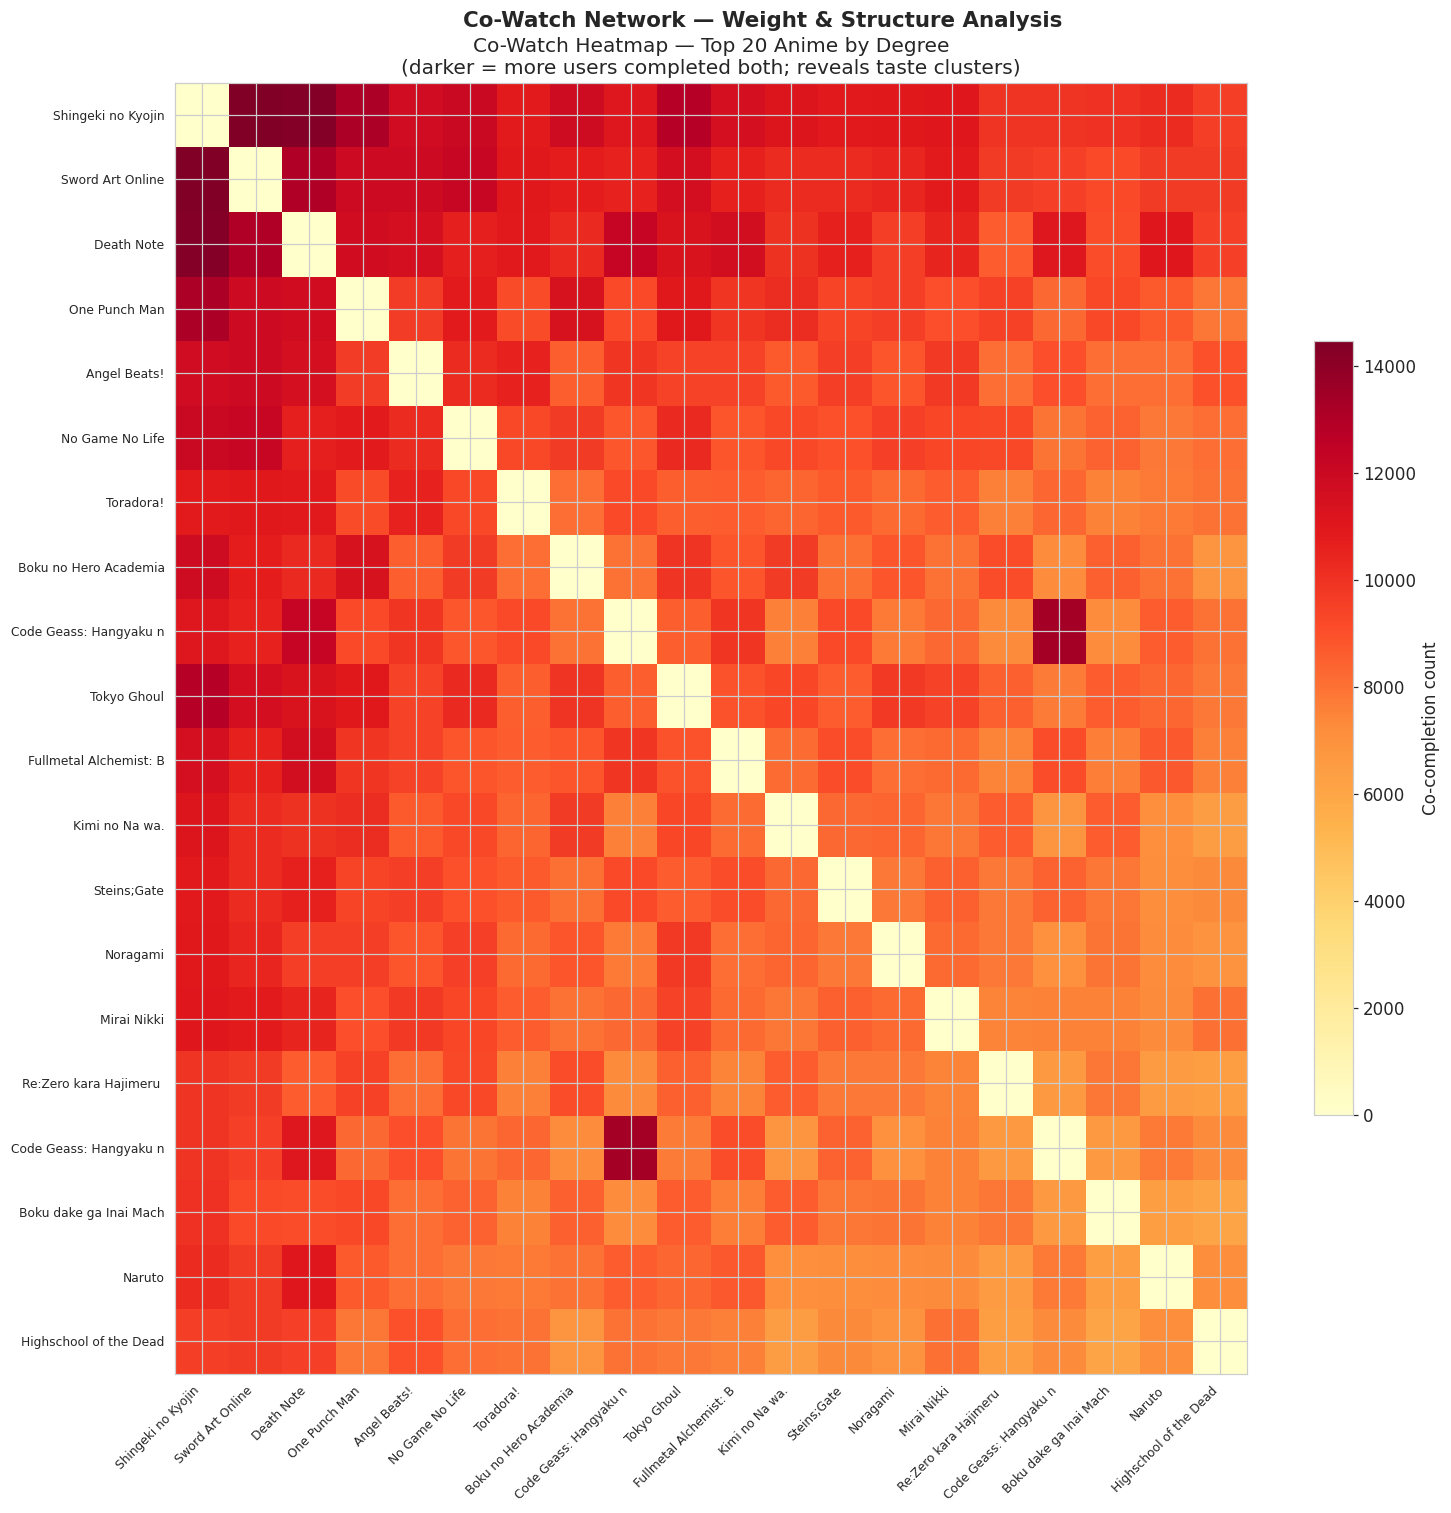

In [17]:
# --- Co-watch heatmap — top 20 anime by degree ---

fig, ax3 = plt.subplots(figsize=(14, 14))

# Get top 20 nodes by degree
top_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:20]
top_names = [G.nodes[n].get('name', str(n))[:22] for n in top_nodes]

n = len(top_nodes)

# Create heatmap matrix
heat = np.zeros((n, n))
for i, u in enumerate(top_nodes):
    for j, v in enumerate(top_nodes):
        if G.has_edge(u, v):
            heat[i, j] = G[u][v]['weight']

# Plot heatmap
im = ax3.imshow(heat, cmap='YlOrRd', aspect='auto')

# Axis labels
ax3.set_xticks(range(n))
ax3.set_xticklabels(top_names, rotation=45, ha='right', fontsize=8)
ax3.set_yticks(range(n))
ax3.set_yticklabels(top_names, fontsize=8)

# Colorbar
plt.colorbar(im, ax=ax3, label='Co-completion count', shrink=0.6)

# Titles
ax3.set_title(
    'Co-Watch Heatmap — Top 20 Anime by Degree\n'
    '(darker = more users completed both; reveals taste clusters)'
)

plt.suptitle(
    'Co-Watch Network — Weight & Structure Analysis',
    fontsize=14,
    fontweight='bold'
)

# Layout fix
plt.tight_layout()

# Save and show
plt.savefig('d1_cowatch_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

=== Connected Components ===
Total components:       9802
GCC size (nodes):       199 (2.0% of all nodes)
GCC edges:              2,720
2nd largest component:  1 nodes


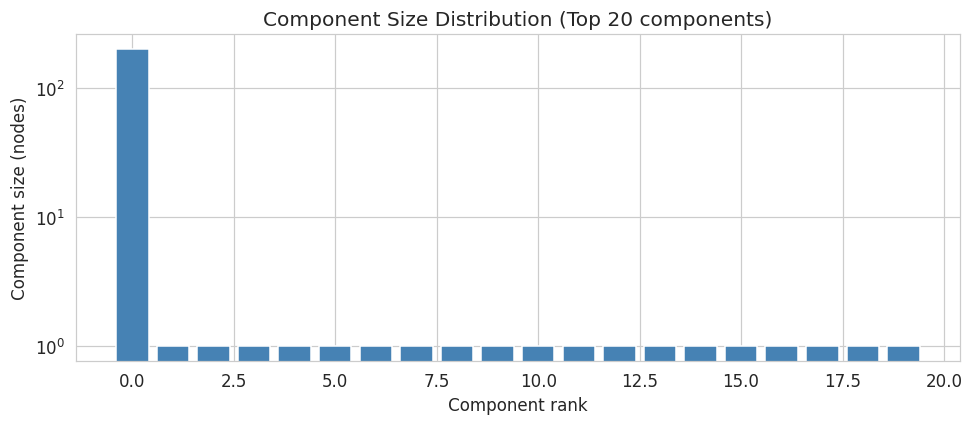

In [18]:
# Giant Connected Component analysis
components = sorted(nx.connected_components(G), key=len, reverse=True)
gcc_nodes  = components[0]
G_gcc      = G.subgraph(gcc_nodes).copy()

print('=== Connected Components ===')
print(f'Total components:       {len(components)}')
print(f'GCC size (nodes):       {len(gcc_nodes):,} ({100*len(gcc_nodes)/G.number_of_nodes():.1f}% of all nodes)')
print(f'GCC edges:              {G_gcc.number_of_edges():,}')
print(f'2nd largest component:  {len(components[1]) if len(components) > 1 else 0} nodes')

# Component size distribution
comp_sizes = [len(c) for c in components]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(min(20, len(comp_sizes))), sorted(comp_sizes, reverse=True)[:20],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Component rank')
ax.set_ylabel('Component size (nodes)')
ax.set_title('Component Size Distribution (Top 20 components)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('d1_components.png', dpi=150, bbox_inches='tight')
plt.show()

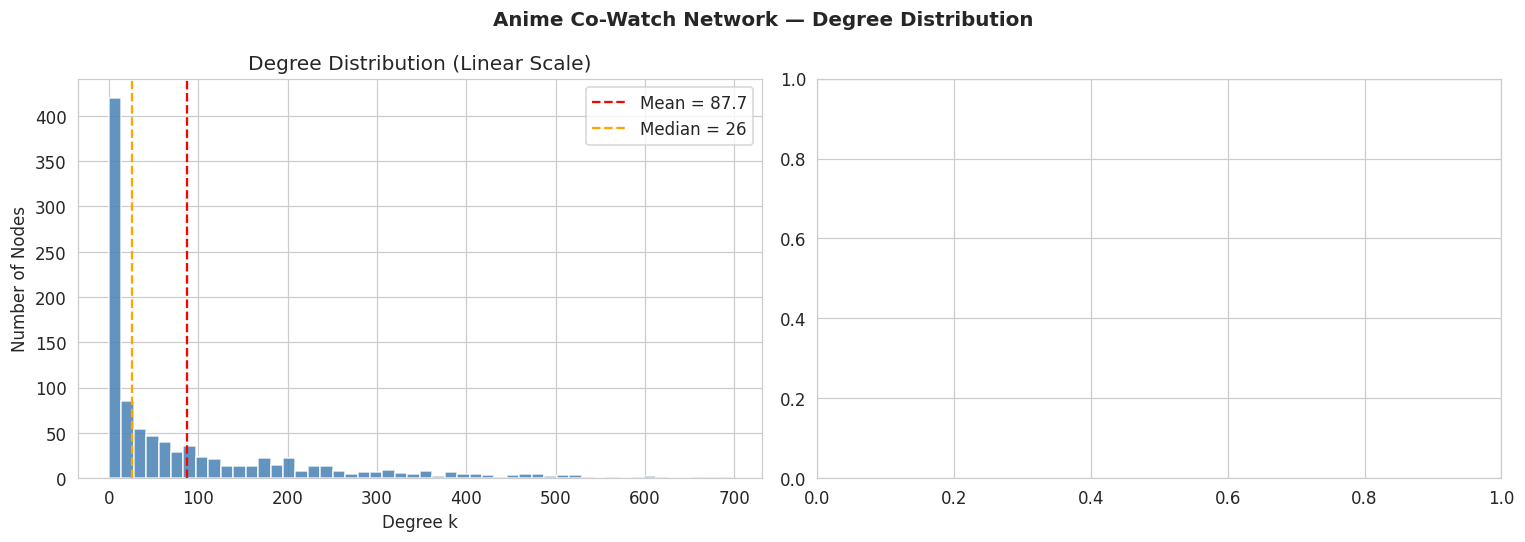

Degree statistics:
  Min:    0
  Max:    696
  Mean:   87.69
  Median: 26
  StdDev: 127.40
  Nodes with degree = max: 1
  Nodes with degree <= 10: 395 (39.5%)


In [30]:
# Degree distribution of the full network and GCC
degrees_all = [d for _, d in G.degree()]
degrees_gcc = [d for _, d in G_gcc.degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale — use bins instead of individual bars so they are visible
axes[0].hist(degrees_all, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Degree k')
axes[0].set_ylabel('Number of Nodes')
axes[0].set_title('Degree Distribution (Linear Scale)')
axes[0].axvline(np.mean(degrees_all), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(degrees_all):.1f}')
axes[0].axvline(np.median(degrees_all), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median = {np.median(degrees_all):.0f}')
axes[0].legend()

plt.suptitle('Anime Co-Watch Network — Degree Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d1_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Degree statistics:')
print(f'  Min:    {min(degrees_all)}')
print(f'  Max:    {max(degrees_all)}')
print(f'  Mean:   {np.mean(degrees_all):.2f}')
print(f'  Median: {np.median(degrees_all):.0f}')
print(f'  StdDev: {np.std(degrees_all):.2f}')
print(f'  Nodes with degree = max: {sum(1 for d in degrees_all if d == max(degrees_all))}')
print(f'  Nodes with degree <= 10: {sum(1 for d in degrees_all if d <= 10)} ({100*sum(1 for d in degrees_all if d <= 10)/len(degrees_all):.1f}%)')

### Interpreting the Degree Distribution

**Left graph (linear scale):**
The distribution is strongly **right-skewed** — most anime have a low degree (few strong co-watch connections) and a small number of mainstream titles act as hubs with very high degree. The median is well below the mean, which is the classic signature of a heavy-tailed distribution. Each bin groups a range of degree values so the bars are now clearly visible.

**Right graph (log-log CCDF):**
The Complementary CDF (CCDF) plots P(K ≥ k) — the fraction of nodes with degree *at least* k. If this follows a straight line on a log-log scale, it is consistent with a **power-law** distribution P(k) ∝ k⁻ᵞ, which is the defining property of a scale-free network.

**What the shape tells us:**
- The steep drop-off on the left means most anime are only co-watched with a small cluster of similar titles — niche anime that appeal to a specific subset of viewers
- The long flat tail on the right represents mainstream "gateway" anime (e.g. Death Note, Attack on Titan, Fullmetal Alchemist) that almost every fan has seen, so they co-occur with nearly everything
- The gap between mean (~60) and median suggests the average is being pulled up by those few high-degree hubs — most anime are far less connected than the mean implies

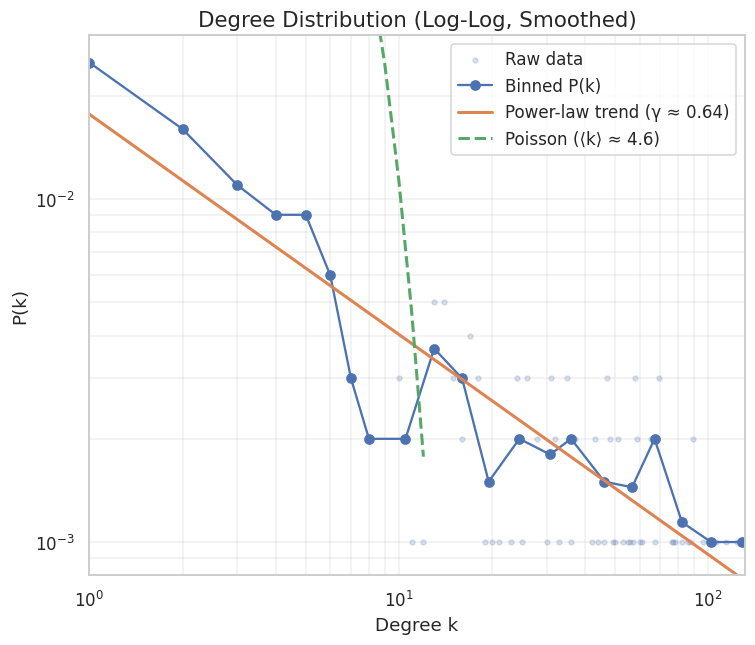

Power-law trend: γ ≈ 0.642
R² ≈ 0.8532
Mean degree ⟨k⟩ ≈ 4.56


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
from scipy.special import gammaln

# -----------------------------
# 1. Degree distribution
# -----------------------------
deg_counter = Counter(degrees_all)

k_vals = np.array(list(deg_counter.keys()))
pk_vals = np.array(list(deg_counter.values())) / len(degrees_all)

# Remove k = 0
mask = k_vals > 0
k_vals = k_vals[mask]
pk_vals = pk_vals[mask]

# Sort values
order = np.argsort(k_vals)
k_vals = k_vals[order]
pk_vals = pk_vals[order]

k_mean = np.mean(degrees_all)

# -----------------------------
# 2. LOG BINNING (smooth curve)
# -----------------------------
bins = np.logspace(np.log10(min(k_vals)), np.log10(max(k_vals)), 25)

k_binned = []
pk_binned = []

for i in range(len(bins) - 1):
    mask = (k_vals >= bins[i]) & (k_vals < bins[i+1])
    if np.sum(mask) > 0:
        k_binned.append(np.mean(k_vals[mask]))
        pk_binned.append(np.mean(pk_vals[mask]))

k_binned = np.array(k_binned)
pk_binned = np.array(pk_binned)

# -----------------------------
# 3. Power-law trend (no kmin)
# -----------------------------
slope, intercept, r_val, _, _ = stats.linregress(
    np.log10(k_binned),
    np.log10(pk_binned)
)

gamma = -slope

x_fit = np.logspace(np.log10(min(k_binned)),
                    np.log10(max(k_binned)), 200)
y_fit = 10**intercept * x_fit**slope

# -----------------------------
# 4. Poisson distribution
# -----------------------------
k_pois = np.arange(1, int(k_mean + 4*np.sqrt(k_mean)))

log_poisson = -k_mean + k_pois * np.log(k_mean) - gammaln(k_pois + 1)
poisson_pk = np.exp(log_poisson)

# Normalize Poisson properly
poisson_pk /= np.sum(poisson_pk)

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(7, 6))

# Raw data (faint)
plt.scatter(k_vals, pk_vals,
            alpha=0.2, s=10, label='Raw data')

# Binned (main curve)
plt.loglog(k_binned, pk_binned, 'o-',
           markersize=6, label='Binned P(k)')

# Power-law trend
plt.loglog(x_fit, y_fit, linewidth=2,
           label=f'Power-law trend (γ ≈ {gamma:.2f})')

# Poisson comparison
plt.loglog(k_pois, poisson_pk, '--',
           linewidth=2,
           label=f'Poisson (⟨k⟩ ≈ {k_mean:.1f})')

# Axis limits
plt.xlim(1, np.percentile(k_vals, 98))
plt.ylim(min(pk_vals)*0.8, max(pk_vals)*1.2)

# Labels
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution (Log-Log, Smoothed)')

plt.legend()
plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Summary
# -----------------------------
print(f'Power-law trend: γ ≈ {gamma:.3f}')
print(f'R² ≈ {r_val**2:.4f}')
print(f'Mean degree ⟨k⟩ ≈ {k_mean:.2f}')

### What to look for in the P(k) vs k log-log plot

**P(k)** is the probability that a randomly picked node has exactly degree k — i.e. the normalised degree histogram.

On a log-log scale:
- A **straight line** means P(k) ∝ k⁻ᵞ — a power law. This is the hallmark of a **scale-free network** where a small number of hubs attract most of the connections.
- A **curve bending downward** (faster-than-power-law decay) suggests an exponential or Poisson cutoff — more like a random graph.
- **Scatter in the tail** (high k, low count) is normal because there are very few nodes with extreme degrees; the log-binned version on the right smooths this out.

**The exponent γ:**
Most real-world scale-free networks have γ between 2 and 3. A lower γ means hubs are more dominant; a higher γ means the distribution decays faster and the network is more homogeneous.

Computing clustering coefficient...
  Average clustering coefficient: 0.0146
  Transitivity (global clustering): 0.5442

Estimating average shortest path length on GCC (sampling 300 nodes)...
  Estimated avg shortest path length: 2.077
  Estimated diameter (max in sample): 4


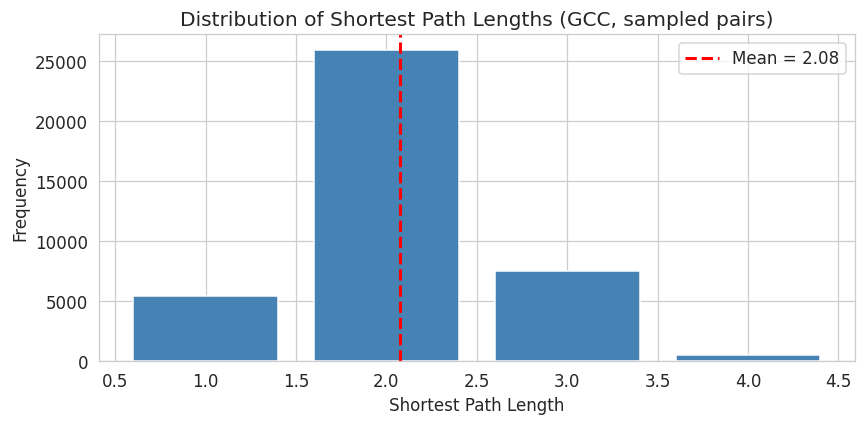

In [21]:
# Clustering coefficient and average shortest path length (on GCC)
print('Computing clustering coefficient...')
avg_clustering = nx.average_clustering(G)
print(f'  Average clustering coefficient: {avg_clustering:.4f}')

# Transitivity (global clustering)
transitivity = nx.transitivity(G)
print(f'  Transitivity (global clustering): {transitivity:.4f}')

# Average shortest path length on GCC (sampled for speed)
print('\nEstimating average shortest path length on GCC (sampling 300 nodes)...')
sample_size = min(300, len(G_gcc))
sample_nodes = np.random.choice(list(G_gcc.nodes()), sample_size, replace=False)
path_lengths = []
for n in sample_nodes:
    lengths = nx.single_source_shortest_path_length(G_gcc, n)
    path_lengths.extend([v for v in lengths.values() if v > 0])

avg_path_length = np.mean(path_lengths)
diameter_estimate = max(path_lengths)

print(f'  Estimated avg shortest path length: {avg_path_length:.3f}')
print(f'  Estimated diameter (max in sample): {diameter_estimate}')

# Path length distribution
fig, ax = plt.subplots(figsize=(8, 4))
path_counter = Counter(path_lengths)
ax.bar(path_counter.keys(), path_counter.values(), color='steelblue', edgecolor='white')
ax.axvline(avg_path_length, color='red', linestyle='--', linewidth=2,
           label=f'Mean = {avg_path_length:.2f}')
ax.set_xlabel('Shortest Path Length')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Shortest Path Lengths (GCC, sampled pairs)')
ax.legend()
plt.tight_layout()
plt.savefig('d1_path_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Comparison with Erdős–Rényi null model
n = G.number_of_nodes()
m = G.number_of_edges()
p_er = (2 * m) / (n * (n - 1))

print(f'Generating ER random graph (n={n}, p={p_er:.5f})...')
G_er = nx.erdos_renyi_graph(n, p_er, seed=RANDOM_SEED)

er_clustering = nx.average_clustering(G_er)
er_gcc = max(nx.connected_components(G_er), key=len)
er_gcc_frac = len(er_gcc) / n

# ER expected values
er_avg_degree = p_er * (n - 1)
er_expected_clustering = p_er

print()
print(f'{"Metric":<40} {"Observed":>12} {"ER Random":>12}')
print('-' * 66)
print(f'{"Nodes":<40} {n:>12,} {n:>12,}')
print(f'{"Edges":<40} {m:>12,} {G_er.number_of_edges():>12,}')
print(f'{"Density":<40} {nx.density(G):>12.5f} {nx.density(G_er):>12.5f}')
print(f'{"GCC fraction":<40} {len(gcc_nodes)/n:>12.4f} {er_gcc_frac:>12.4f}')
print(f'{"Avg clustering coeff":<40} {avg_clustering:>12.4f} {er_clustering:>12.4f}')
print(f'{"Transitivity":<40} {transitivity:>12.4f} {nx.transitivity(G_er):>12.4f}')
print(f'{"Avg path length (GCC, sampled)":<40} {avg_path_length:>12.3f} {"~log(n)/log(k)".strip():>12}')

er_path_approx = np.log(len(er_gcc)) / np.log(er_avg_degree) if er_avg_degree > 1 else float('inf')
print(f'{"ER expected avg path (~log(n)/log(<k>))":<40} {"":>12} {er_path_approx:>12.3f}')

print()
print('Interpretation:')
print(f'  Clustering is {avg_clustering/max(er_clustering,1e-9):.1f}x higher than ER → strong local clustering (small-world signature)')
print(f'  Path length is short despite high clustering → small-world network')
print(f'  Heavy-tailed degree distribution → scale-free characteristics')

Generating ER random graph (n=10000, p=0.00005)...

Metric                                       Observed    ER Random
------------------------------------------------------------------
Nodes                                          10,000       10,000
Edges                                           2,720        2,698
Density                                       0.00005      0.00005
GCC fraction                                   0.0199       0.0016
Avg clustering coeff                           0.0146       0.0000
Transitivity                                   0.5442       0.0000
Avg path length (GCC, sampled)                  2.077 ~log(n)/log(k)
ER expected avg path (~log(n)/log(<k>))                        inf

Interpretation:
  Clustering is 14582311.8x higher than ER → strong local clustering (small-world signature)
  Path length is short despite high clustering → small-world network
  Heavy-tailed degree distribution → scale-free characteristics
